In [23]:
from datasets import load_dataset
import sounddevice as sd # To run sound using data as array and the sample rate
from torch.utils.data import DataLoader
import numpy as np
from matplotlib import pyplot as plt
import torch
import torch.nn as nn

In [ ]:
!pip install sounddevice

In [ ]:
dataset1 = load_dataset("MBZUAI/ClArTTS")
dataset2 = load_dataset("MohamedRashad/common-voice-18-arabic")
# dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [3]:
help(load_dataset)

Help on function load_dataset in module datasets.load:

load_dataset(path: str, name: Optional[str] = None, data_dir: Optional[str] = None, data_files: Union[str, collections.abc.Sequence[str], collections.abc.Mapping[str, Union[str, collections.abc.Sequence[str]]], NoneType] = None, split: Union[str, datasets.splits.Split, list[str], list[datasets.splits.Split], NoneType] = None, cache_dir: Optional[str] = None, features: Optional[datasets.features.features.Features] = None, download_config: Optional[datasets.download.download_config.DownloadConfig] = None, download_mode: Union[datasets.download.download_manager.DownloadMode, str, NoneType] = None, verification_mode: Union[datasets.utils.info_utils.VerificationMode, str, NoneType] = None, keep_in_memory: Optional[bool] = None, save_infos: bool = False, revision: Union[datasets.utils.version.Version, str, NoneType] = None, token: Union[bool, str, NoneType] = None, streaming: bool = False, num_proc: Optional[int] = None, storage_options

# Notes

## Augmentation Related
### Note 1
The model should be time wrapping invariance (able to handle different sampling rate)
To that end, it is important to have a resampling augmentation
### Note 2
The input can be as long as 40100 data points if the model were to handle one second at a time.
This can make the model quite large, thus, this input will need to be split, or projected down
to make sure the model size will stay relatively small.


## Architecture Related
### Note 1
Using an encoder and decoder together might be better than just using an encoder or a decoder.
The idea is the encoder will get information about a larger chunk, let's say 5-10 seconds, while
the decoder will process 1 second at a time. This means the encoder will gain insight about 
a larger chunk, (more global attention), this means it will figure out which sound effect to 
remove and which one to keep. Maybe a sound effect is needed, such as a mouse click, and maybe
it is noise, so this larger attention might help in those kind of scenarios.

# Visualizing Data

In [28]:
dataset1.keys()

dict_keys(['train', 'test'])

In [27]:
dataset1["train"][0].keys()

dict_keys(['text', 'file', 'audio', 'sampling_rate', 'duration'])

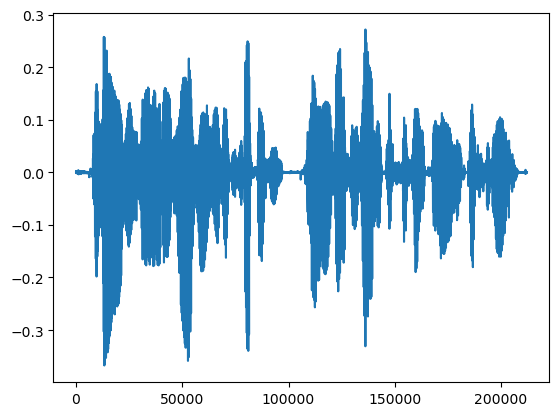

In [20]:
plt.plot(dataset1["train"][0]["audio"])

In [40]:
exampleAudioI = 1000
audio_e_data = dataset1["train"][exampleAudioI]["audio"]
audio_e_samplerate = dataset1["train"][exampleAudioI]["sampling_rate"]

In [41]:
sd.play(data=audio_e_data, samplerate=audio_e_samplerate)

# Dataset Augmentation

# Model

In [ ]:
class MusicRemoverLayer(nn.Module):
    def __init__(self, chunk_size, d_model=32, nhead=4):
        super().__init__()

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            dropout=0.1, # default
            activation="gelu",
            bias=True,
            nhead=nheads, # Might be better to have multiple head, each focusing on different type of info
            dim_feedforward=chunk_size,
            batch_first=True, # Shape (B, Seq, D_model)
        )
        self.transformer = nn.TransformerEncoder(encoder_layer)

    def forward(self, x): # Input must be (B, Seq, D_model)!
        music_noise = self.transformer(x)
        cleaned_x = (x - noise)
        return cleaned_x

In [ ]:
# class Decoder(nn.Module):
#     def __init__(self, chunk_size, d_model, nhead):
#         self.
        

In [ ]:
# class MusicRemoverModel(L.LightningModule):
#     def __init__(self, chunk_size=250, d_model=32, nhead=4):
        